In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

n = 50  # 50 fictional countries

df = pd.DataFrame({
    'country': ['Country_' + str(i) for i in range(1, n+1)],
    'conflict_intensity': np.random.exponential(scale=3, size=n).clip(0, 10),
    'military_spending_pct_gdp': np.random.normal(2.5, 1.5, n).clip(0.5, 8),
    'political_stability': np.random.normal(5, 2.5, n).clip(0, 10),
    'cyber_threat_level': np.random.normal(5, 2, n).clip(0, 10),
    'gdp_per_capita': np.random.exponential(scale=15000, size=n).clip(500, 70000)
})

print(df.shape)
display(df.head(10))
display(df.describe().round(1))

(50, 6)


,country,conflict_intensity,military_spending_pct_gdp,political_stability,cyber_threat_level,gdp_per_capita
0,Country_1,1.407804,3.607700,5.242694,5.454920,28570.899787
1,Country_2,9.030364,2.757052,7.421612,7.614286,5717.193471
2,Country_3,3.950237,2.326528,3.244867,1.785034,2785.779244
3,Country_4,2.738828,2.048344,4.180845,5.369268,12206.054881
4,Country_5,0.508875,0.500000,4.019730,5.519766,41269.402062
5,Country_6,0.508789,1.420234,1.341213,6.563646,17862.383966
6,Country_7,0.179516,1.809042,5.740301,2.526099,12661.685047
7,Country_8,6.033693,4.085683,5.652638,2.359087,1533.422960
8,Country_9,2.757246,3.015427,5.012784,6.043883,14317.960733
9,Country_10,3.693750,0.500000,4.413532,5.593969,69158.546218


,conflict_intensity,military_spending_pct_gdp,political_stability,cyber_threat_level,gdp_per_capita
count,50.0,50.0,50.0,50.0,50.0
mean,2.5,2.6,4.8,5.2,14805.4
std,2.6,1.2,2.3,1.8,13085.9
min,0.1,0.5,0.2,1.8,500.0
25%,0.6,1.7,3.1,3.5,5339.4
50%,1.7,2.5,4.9,5.5,11970.2
75%,3.2,3.6,5.9,6.3,21596.2
max,10.0,4.8,10.0,10.0,69158.5


In [ ]:
# We scale because KMeans is sensitive to the size of numbers
# gdp_per_capita goes up to 70,000 while other variables go up to 10
# Without scaling, GDP would completely dominate the clustering
# just because its numbers are bigger — not because it's more important

features = ['conflict_intensity', 'military_spending_pct_gdp',
            'political_stability', 'cyber_threat_level',
            'gdp_per_capita']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("Before scaling — GDP average:", df['gdp_per_capita'].mean().round(1))
print("After scaling — GDP average:", X_scaled[:, 4].mean().round(4))
print("\nAll variables now on the same scale:")
print(pd.DataFrame(X_scaled, columns=features).describe().round(2))

Before scaling — GDP average: 14805.4
After scaling — GDP average: -0.0

All variables now on the same scale:
       conflict_intensity  military_spending_pct_gdp  political_stability  \
count               50.00                      50.00                50.00   
mean                 0.00                      -0.00                -0.00   
std                  1.01                       1.01                 1.01   
min                 -0.94                      -1.72                -2.00   
25%                 -0.73                      -0.70                -0.75   
50%                 -0.31                      -0.03                 0.02   
75%                  0.24                       0.82                 0.48   
max                  2.86                       1.89                 2.24   

       cyber_threat_level  gdp_per_capita  
count               50.00           50.00  
mean                 0.00           -0.00  
std                  1.01            1.01  
min                 

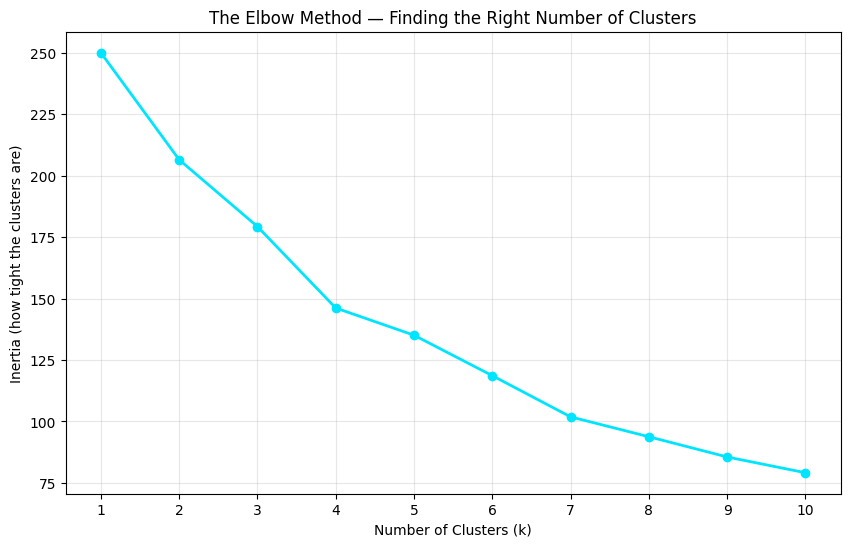

In [ ]:
# We're going to try clustering with different numbers of clusters
# from 1 to 10, and measure how "tight" each clustering is

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o', color='#00e5ff', linewidth=2)
plt.title('The Elbow Method — Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (how tight the clusters are)')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# We go with 3 clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# See how many countries ended up in each cluster
print("Countries per cluster:")
print(df['cluster'].value_counts().sort_index())

# Look at the average profile of each cluster
print("\nAverage characteristics per cluster:")
display(df.groupby('cluster')[features].mean().round(2))

Countries per cluster:
cluster
0    16
1    26
2     8
Name: count, dtype: int64

Average characteristics per cluster:


,conflict_intensity,military_spending_pct_gdp,political_stability,cyber_threat_level,gdp_per_capita
cluster,,,,,
0,2.32,2.23,6.03,3.63,17480.17
1,1.33,2.86,3.48,5.77,15416.24
2,6.81,2.31,6.76,6.54,7470.77


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

n = 300  # 300 historical cyber incidents

# Generate incident characteristics
df = pd.DataFrame({
    'attack_duration_hours': np.random.exponential(scale=10, size=n).clip(0.5, 72),
    'systems_compromised': np.random.randint(1, 500, n),
    'data_volume_gb': np.random.exponential(scale=50, size=n).clip(0, 500),
    'response_time_hours': np.random.normal(5, 3, n).clip(0.5, 24),
    'is_insider_threat': np.random.choice([0, 1], size=n, p=[0.8, 0.2])
})

# Create threat level labels based on the variables
# This mimics how a real analyst would have labeled historical incidents
conditions = [
    (df['systems_compromised'] > 300) | (df['data_volume_gb'] > 300),
    (df['systems_compromised'] > 100) | (df['data_volume_gb'] > 100),
]
choices = ['High', 'Medium']
df['threat_level'] = np.select(conditions, choices, default='Low')

print("Dataset shape:", df.shape)
print("\nThreat level distribution:")
print(df['threat_level'].value_counts())
display(df.head(10))

Dataset shape: (300, 6)

Threat level distribution:
threat_level
Medium    130
High      115
Low        55
Name: count, dtype: int64


,attack_duration_hours,systems_compromised,data_volume_gb,response_time_hours,is_insider_threat,threat_level
0,4.692681,365,28.497992,10.117475,1,High
1,30.101214,480,14.630186,4.903009,0,High
2,13.167457,372,25.976679,7.484460,0,High
3,9.129426,350,42.370080,8.029685,0,High
4,1.696249,47,67.541315,3.509423,0,Low
5,1.695963,355,72.877673,6.163535,0,High
6,0.598388,311,86.521090,6.976115,1,High
7,20.112309,424,68.170248,2.272527,0,High
8,9.190822,308,57.134389,9.926289,0,High
9,12.312501,144,13.558063,4.883563,0,Medium


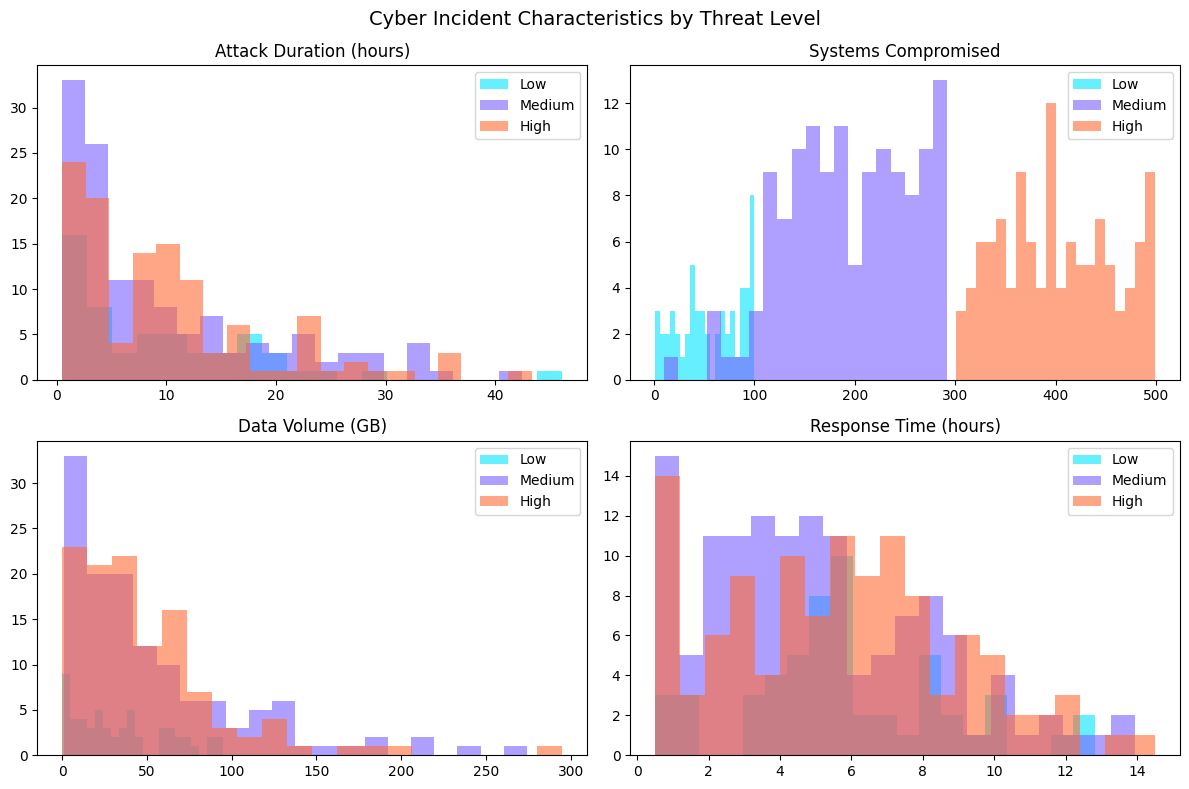

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Cyber Incident Characteristics by Threat Level', fontsize=14)

variables = ['attack_duration_hours', 'systems_compromised',
             'data_volume_gb', 'response_time_hours']
titles = ['Attack Duration (hours)', 'Systems Compromised',
          'Data Volume (GB)', 'Response Time (hours)']
colors = {'Low': '#00e5ff', 'Medium': '#7b61ff', 'High': '#ff6b35'}

for ax, var, title in zip(axes.flatten(), variables, titles):
    for threat_level, color in colors.items():
        data = df[df['threat_level'] == threat_level][var]
        ax.hist(data, bins=20, alpha=0.6, color=color, label=threat_level)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Define features and target
features = ['attack_duration_hours', 'systems_compromised',
            'data_volume_gb', 'response_time_hours',
            'is_insider_threat']

X = df[features]
y = df['threat_level']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
predictions = model.predict(X_test_scaled)

# Basic accuracy
print(f"Model accuracy: {accuracy_score(y_test, predictions):.1%}")

Model accuracy: 100.0%


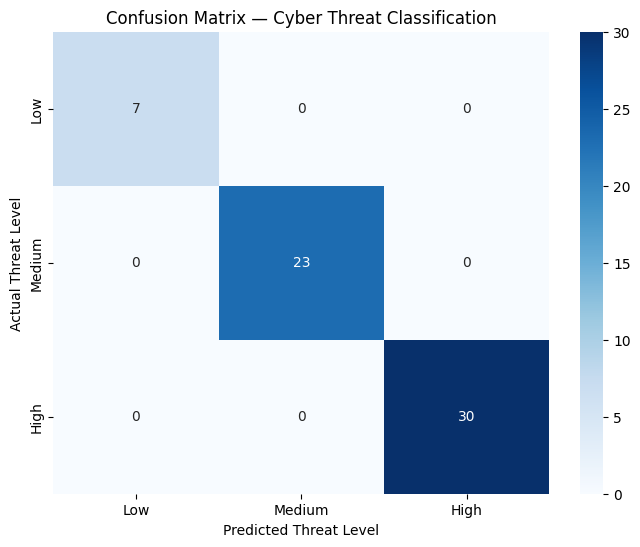

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        30
         Low       1.00      1.00      1.00         7
      Medium       1.00      1.00      1.00        23

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [ ]:
# A confusion matrix shows us WHERE the model makes mistakes
# not just how many it gets right overall

cm = confusion_matrix(y_test, predictions, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.title('Confusion Matrix — Cyber Threat Classification')
plt.ylabel('Actual Threat Level')
plt.xlabel('Predicted Threat Level')
plt.show()

# More detailed breakdown
print(classification_report(y_test, predictions))

                 Feature  Importance
1    systems_compromised    0.823222
2         data_volume_gb    0.069604
3    response_time_hours    0.058419
0  attack_duration_hours    0.045624
4      is_insider_threat    0.003131


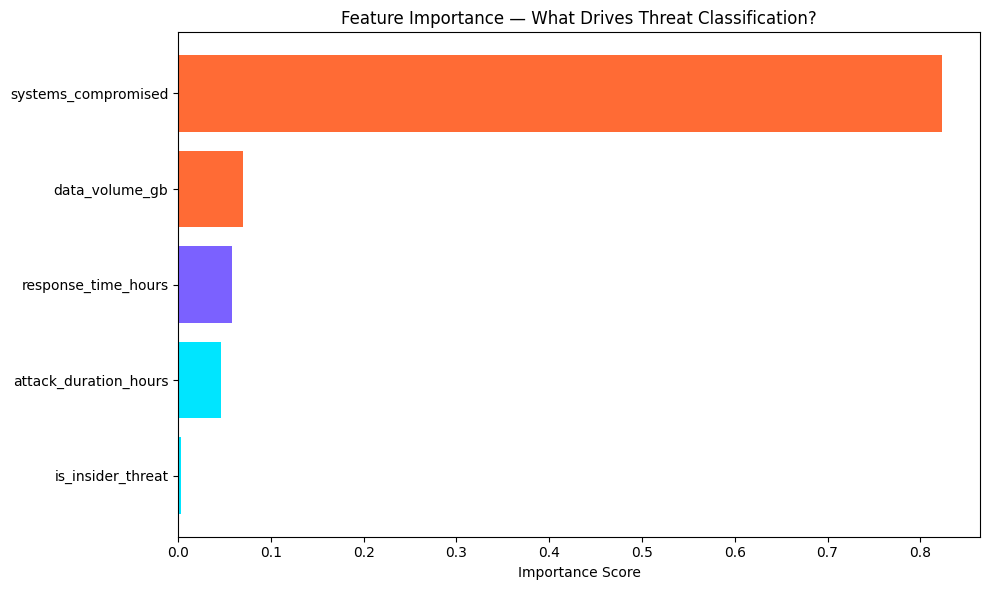

In [ ]:
# Which variables did the model rely on most to classify threat levels?

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

plt.figure(figsize=(10, 6))
colors = ['#ff6b35', '#ff6b35', '#7b61ff', '#00e5ff', '#00e5ff']
plt.barh(importance['Feature'], importance['Importance'], color=colors)
plt.title('Feature Importance — What Drives Threat Classification?')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()